In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("leucemia_dataset.csv")
df.head(2)

,Patient_ID,Age,Gender,Country,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,Genetic_Mutation,...,Alcohol_Consumption,Radiation_Exposure,Infection_History,BMI,Chronic_Illness,Immune_Disorders,Ethnicity,Socioeconomic_Status,Urban_Rural,Leukemia_Status
0,1,52,Male,China,2698,5.36,262493,12.2,72,Yes,...,No,No,No,24.0,No,No,Ethnic_Group_B,Low,Rural,Negative
1,2,15,Female,China,4857,4.81,277877,11.9,97,Yes,...,No,No,No,28.7,No,No,Ethnic_Group_A,Low,Urban,Positive


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143194 entries, 0 to 143193
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Patient_ID            143194 non-null  int64  
 1   Age                   143194 non-null  int64  
 2   Gender                143194 non-null  object 
 3   Country               143194 non-null  object 
 4   WBC_Count             143194 non-null  int64  
 5   RBC_Count             143194 non-null  float64
 6   Platelet_Count        143194 non-null  int64  
 7   Hemoglobin_Level      143194 non-null  float64
 8   Bone_Marrow_Blasts    143194 non-null  int64  
 9   Genetic_Mutation      143194 non-null  object 
 10  Family_History        143194 non-null  object 
 11  Smoking_Status        143194 non-null  object 
 12  Alcohol_Consumption   143194 non-null  object 
 13  Radiation_Exposure    143194 non-null  object 
 14  Infection_History     143194 non-null  object 
 15  

# Columna "Country" la cambiaremos por "Distrito"

In [5]:
df.Country.value_counts()

Country
India           23083
USA             22777
Brazil          15232
Russia          15217
China           15147
UK               3165
Mexico           3160
Turkey           3126
South Korea      3072
Canada           3068
Australia        3063
Sweden           3061
South Africa     3057
Netherlands      3045
Japan            3014
Norway           3006
Argentina        3001
France           3000
Germany          2988
Saudi Arabia     2976
Italy            2973
Spain            2963
Name: count, dtype: int64

In [4]:
df = df.drop(columns="Country")

dist_list = ["Ate", "La Molina", "Barranco", "Surco", "Surquillo", "San Borja", "San Juan de Miraflores", 
             "Miraflores", "Villa María del Triunfo", "Comas", "San Miguel"]
df["District"] = [dist_list[np.random.randint(0, len(dist_list))] for a in range(df.shape[0])]

In [5]:
df.District.value_counts()

District
Ate                        13188
San Miguel                 13164
Villa María del Triunfo    13083
La Molina                  13040
Comas                      13039
Barranco                   12979
Miraflores                 12976
Surco                      12956
San Juan de Miraflores     12935
San Borja                  12917
Surquillo                  12917
Name: count, dtype: int64

# Preprocesamiento de variables categóricas

In [6]:
le = LabelEncoder()

cat = df.select_dtypes("object")

for col in cat.columns:
    df[col] = le.fit_transform(df[col])

In [30]:
df.head(10)

,Patient_ID,Age,Gender,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,Genetic_Mutation,Family_History,Smoking_Status,Alcohol_Consumption,Radiation_Exposure,Infection_History,BMI,Chronic_Illness,Immune_Disorders,Ethnicity,Socioeconomic_Status,Urban_Rural,Leukemia_Status,District
0,1,52,1,2698,5.36,262493,12.2,72,1,0,1,0,0,0,24.0,0,0,1,1,0,0,4
1,2,15,0,4857,4.81,277877,11.9,97,1,0,0,0,0,0,28.7,0,0,0,1,1,1,5
2,3,72,1,9614,5.17,319600,13.4,94,0,1,0,1,0,0,27.7,0,0,1,1,1,0,0
3,4,61,1,6278,5.41,215200,11.6,50,0,0,1,0,0,0,31.6,0,0,0,2,0,0,3
4,5,21,1,8342,4.78,309169,14.3,28,0,0,1,0,0,0,22.3,0,0,1,1,0,0,1
5,6,83,1,5676,5.20,291346,12.2,62,0,0,1,0,0,0,19.1,1,0,0,1,1,0,8
6,7,87,1,8858,4.81,134683,11.0,83,0,0,0,1,0,0,31.6,0,0,2,0,1,1,0
7,8,75,0,9633,4.73,246882,13.8,3,0,1,1,1,1,0,21.2,0,0,0,1,1,0,3
8,9,75,1,7387,5.28,202453,14.5,12,0,1,0,0,0,0,30.8,0,0,0,1,1,0,7
9,10,88,0,4624,5.90,214921,12.4,65,0,1,0,1,0,0,19.8,0,0,0,2,0,0,3


# Evaluamos variables para el modelo

<Axes: >

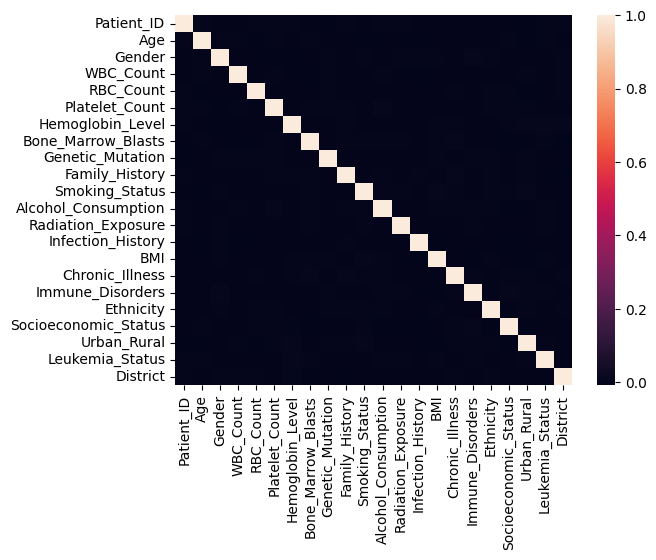

In [7]:
num = df.select_dtypes(["float64", "int64"])
sns.heatmap(num.corr())

In [31]:
df.head(1)

,Patient_ID,Age,Gender,WBC_Count,RBC_Count,Platelet_Count,Hemoglobin_Level,Bone_Marrow_Blasts,Genetic_Mutation,Family_History,Smoking_Status,Alcohol_Consumption,Radiation_Exposure,Infection_History,BMI,Chronic_Illness,Immune_Disorders,Ethnicity,Socioeconomic_Status,Urban_Rural,Leukemia_Status,District
0,1,52,1,2698,5.36,262493,12.2,72,1,0,1,0,0,0,24.0,0,0,1,1,0,0,4


In [8]:
X = df.drop(columns=["Patient_ID", "Leukemia_Status", "District"], axis=1)
y = df["Leukemia_Status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creación y entrenamiento de modelo

In [9]:
rf = RandomForestClassifier(n_estimators= 200, random_state=42)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)
print(accuracy_score(y_test, pred))

0.84947100108244


<Axes: title={'center': 'Clases con mayor influencia durante entrenamiento del modelo Random Forest'}>

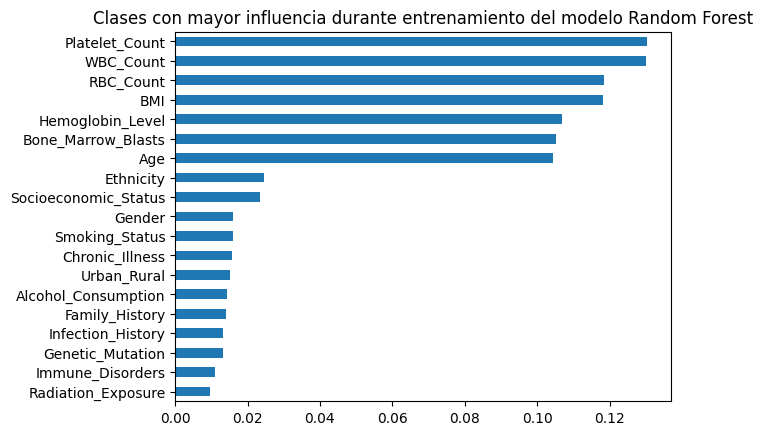

In [12]:
br = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.title("Clases con mayor influencia durante entrenamiento del modelo Random Forest")
br.plot.barh()